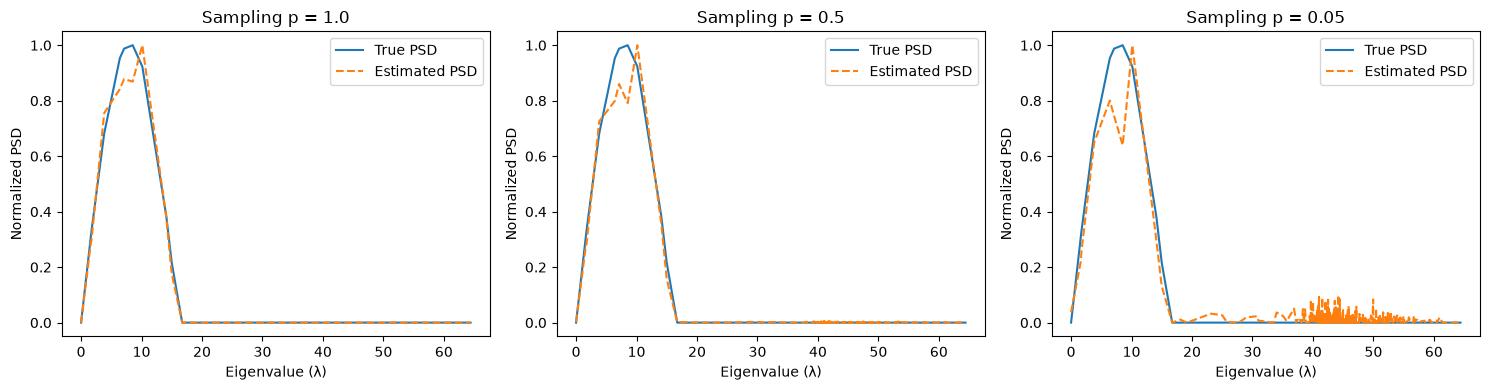

In [ ]:
from src.additional.preliminary_tests import run_psd_experiment
_=run_psd_experiment(M =100)

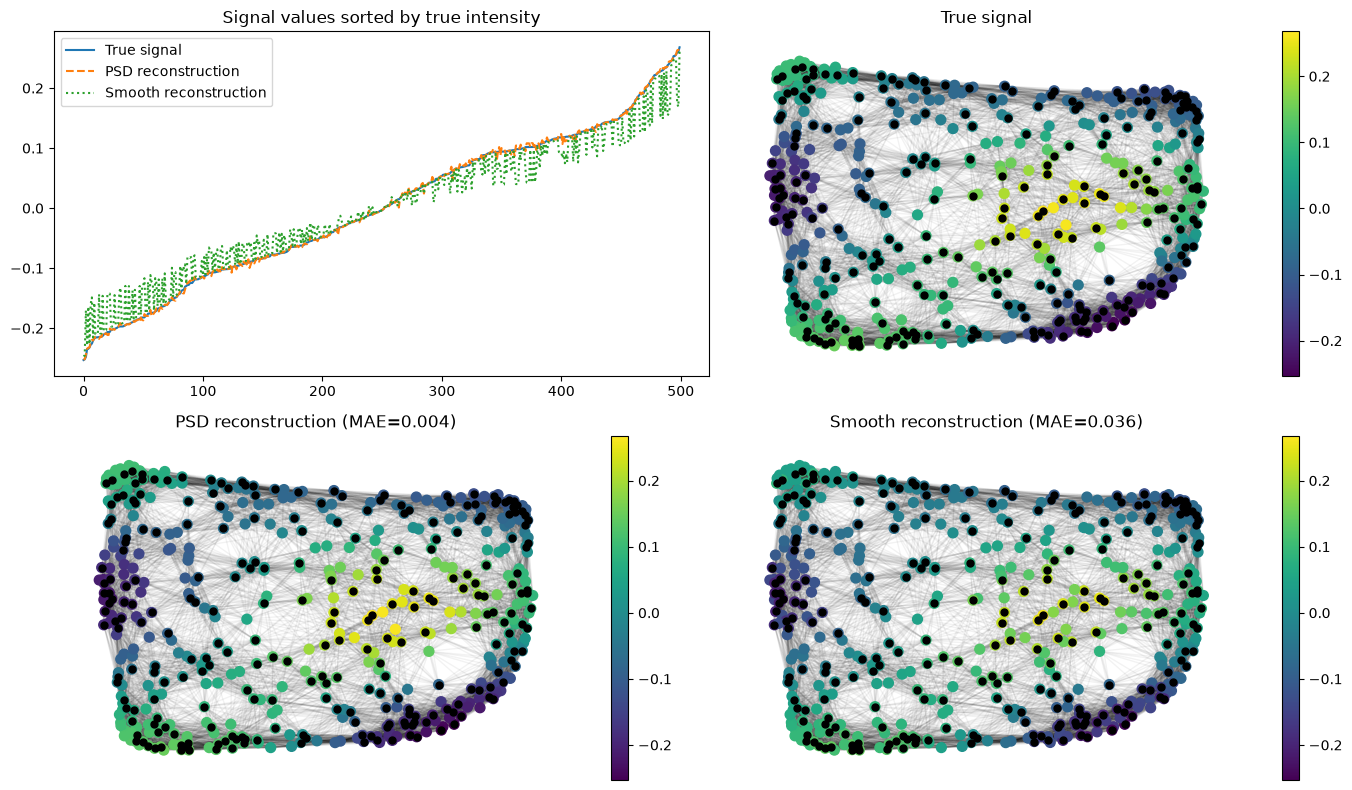

In [5]:
from src.additional.preliminary_tests import reconstruction_experiment
_=reconstruction_experiment(M_train=100,gm_beta=0.002,beta =0.002)

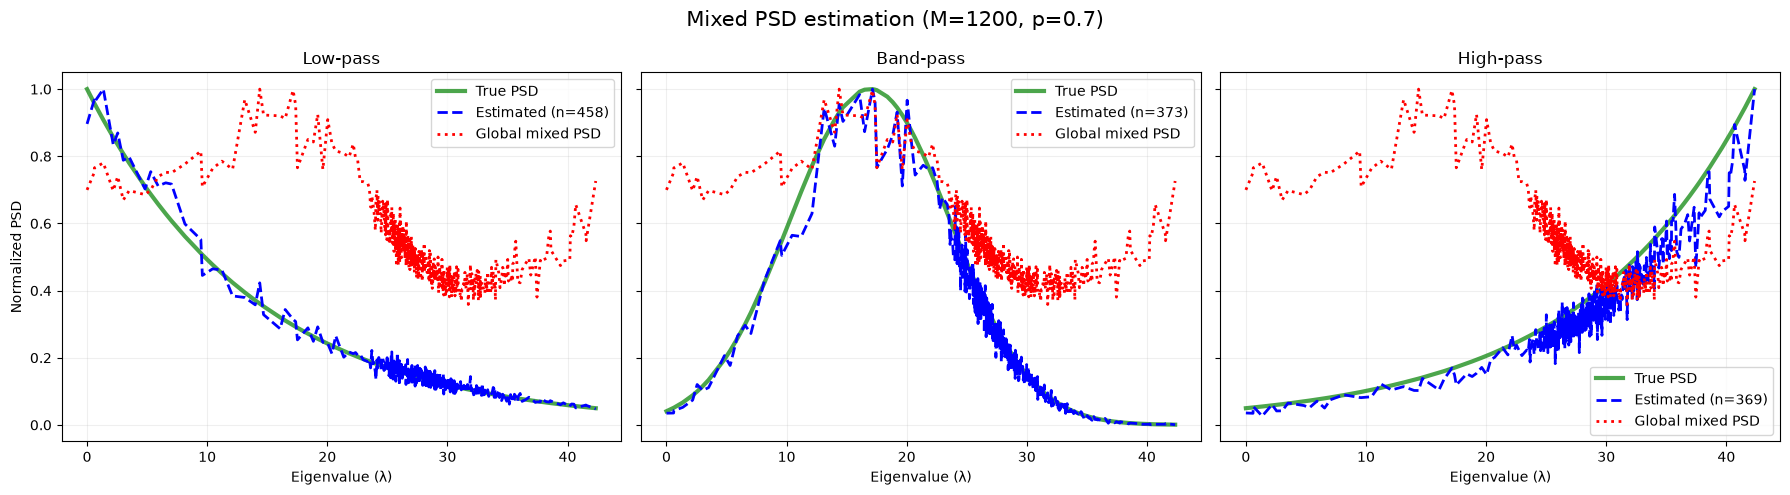

In [ ]:
from src.additional.preliminary_tests import run_mixed_psd_estimation_exp
_= run_mixed_psd_estimation_exp()

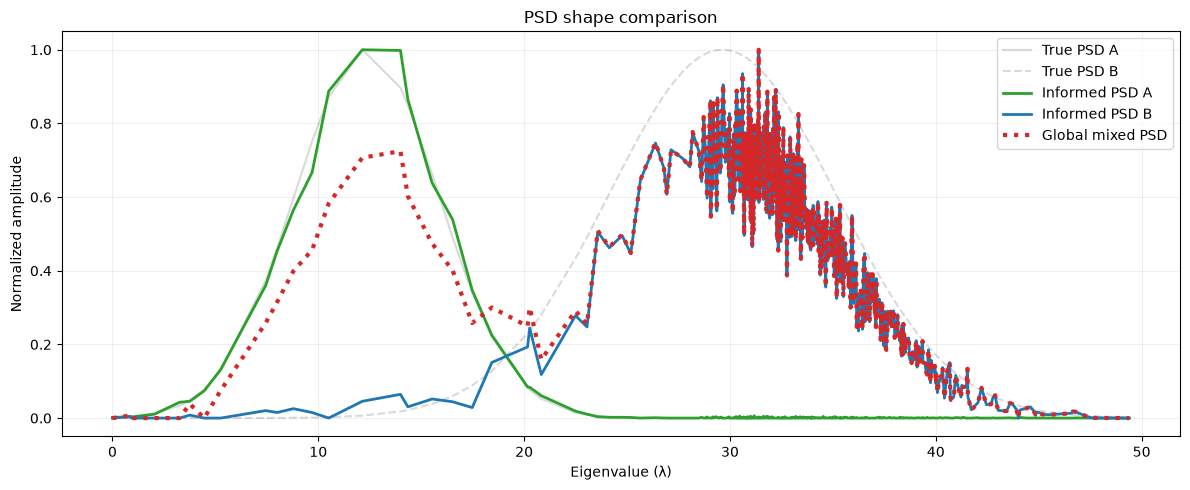

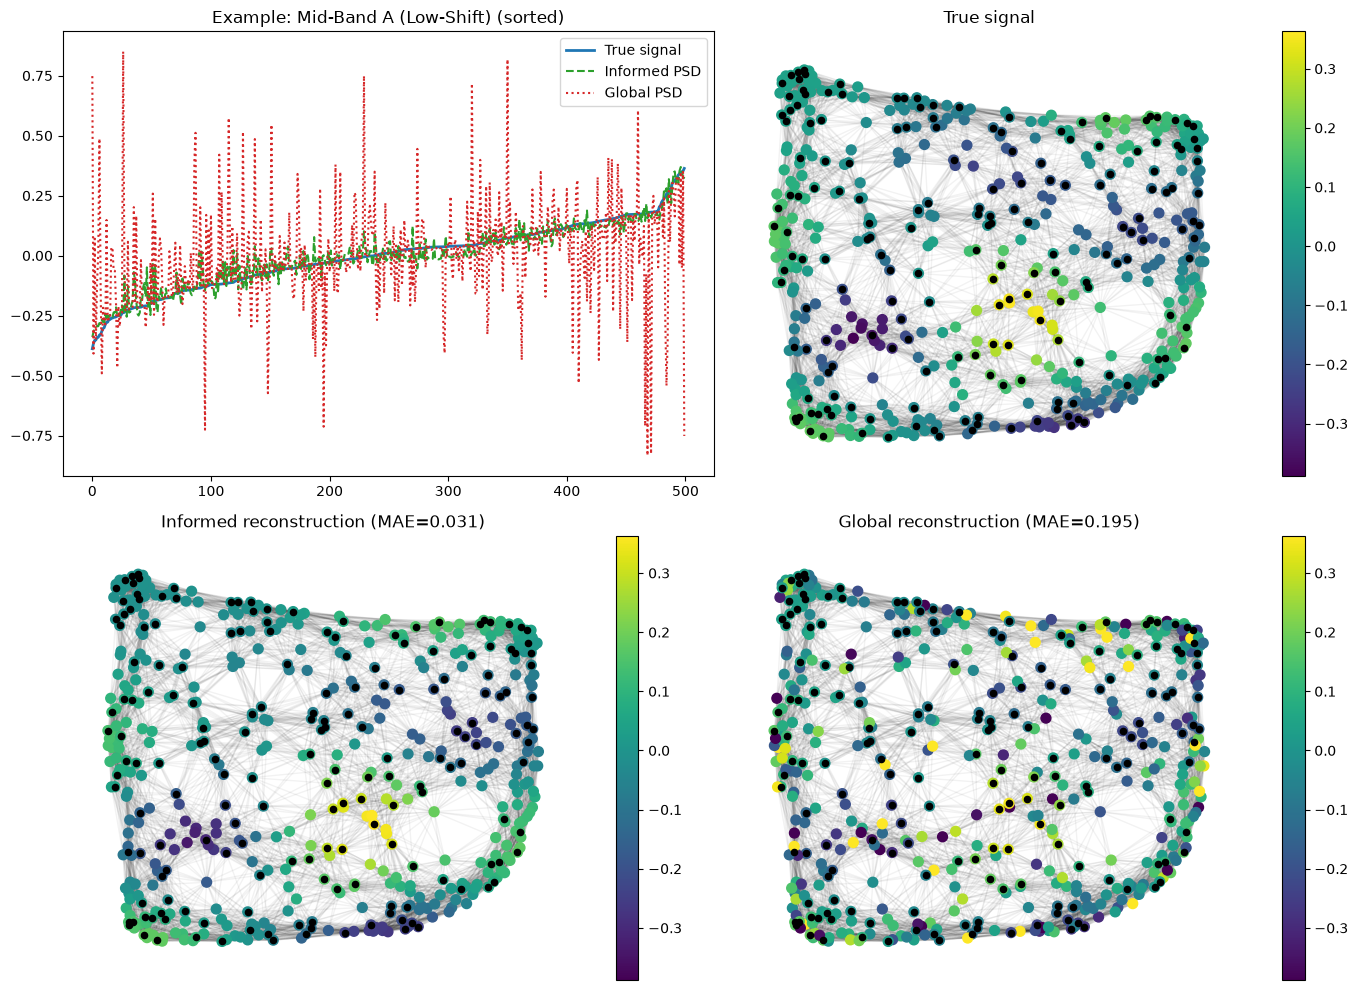

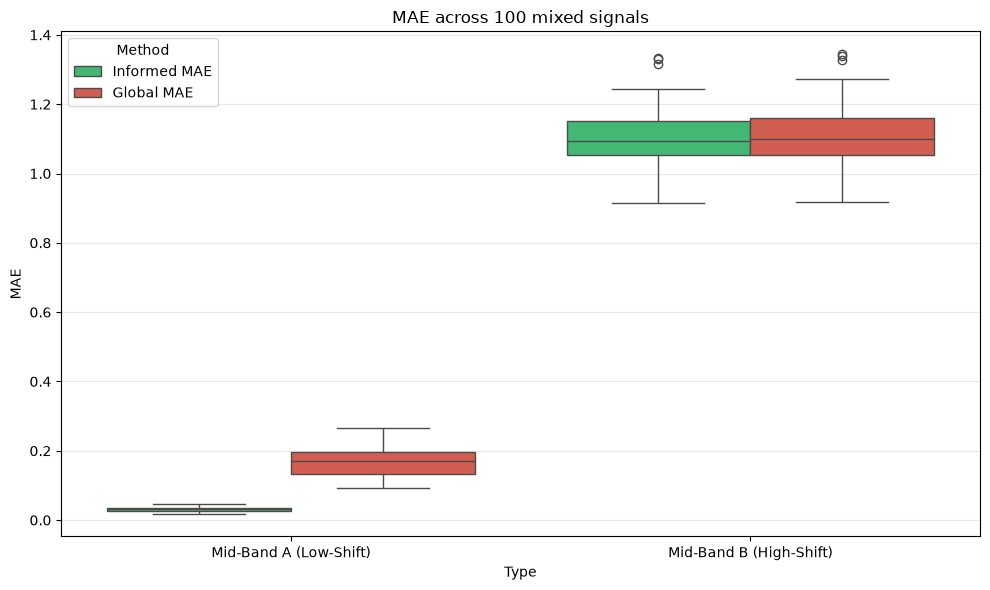

,Type,Informed MAE,Global MAE
0,Mid-Band B (High-Shift),1.170779,1.169806
1,Mid-Band B (High-Shift),1.023410,1.052772
2,Mid-Band A (Low-Shift),0.039675,0.195804
3,Mid-Band A (Low-Shift),0.037000,0.180054
4,Mid-Band A (Low-Shift),0.034408,0.153212
...,...,...,...
95,Mid-Band A (Low-Shift),0.033524,0.141498
96,Mid-Band B (High-Shift),1.055198,1.048161
97,Mid-Band A (Low-Shift),0.034395,0.159445
98,Mid-Band B (High-Shift),1.116692,1.118431


In [11]:
from src.additional.preliminary_tests import run_mixed_comparison_experiment
run_mixed_comparison_experiment()

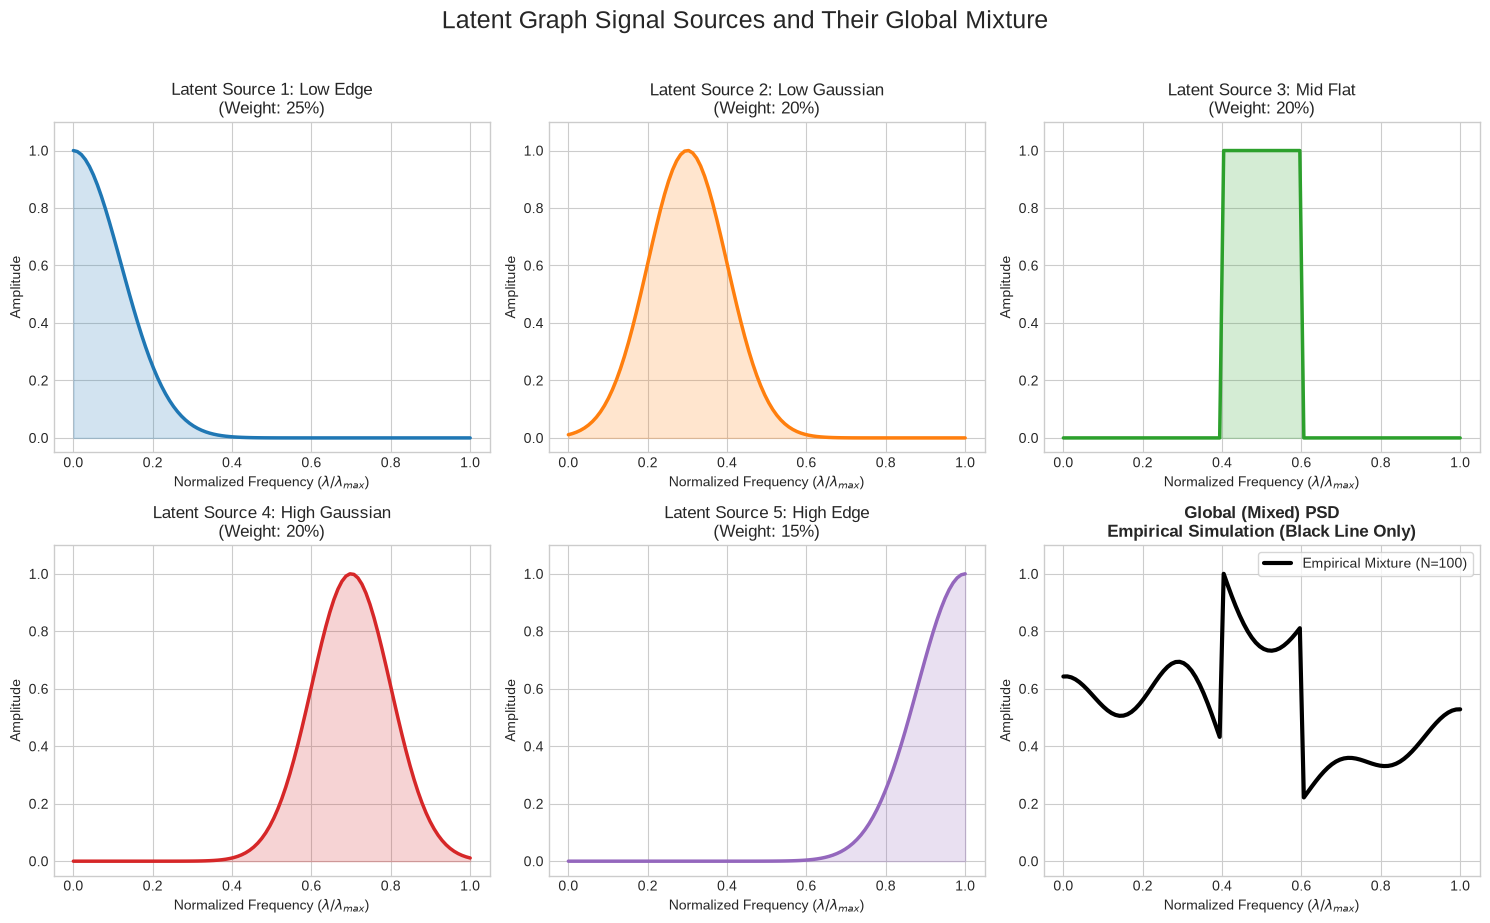

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from src.experiments._helper import edge_skewed_psd, gaussian_psd, flat_band_psd

REFERENCE_PSD_PROFILES = (
    edge_skewed_psd(scale=0.12, side="low"),
    gaussian_psd(mean=0.30, variance=0.010),
    flat_band_psd(low=0.40, high=0.60),
    gaussian_psd(mean=0.70, variance=0.010),
    edge_skewed_psd(scale=0.12, side="high"),
)

REFERENCE_PSD_PROBABILITIES = (0.25, 0.20, 0.20, 0.20, 0.15)

# Odtworzenie listy 'profiles' (nazwy, funkcje, prawdopodobieństwa, kolory)
names = ["Low Edge", "Low Gaussian", "Mid Flat", "High Gaussian", "High Edge"]
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']
profiles = list(zip(names, REFERENCE_PSD_PROFILES, REFERENCE_PSD_PROBABILITIES, colors))

# =============================================================================
# 3. Grid Visualization Setup
# =============================================================================

plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

# Znormalizowana częstotliwość x w [0, 1]
# Będziemy ją przekazywać jako 'eigenvalues' z lambda_max=1.0
x = np.linspace(0, 1, 100)
lambda_max_val = 1.0

# Plot the 5 individual latent components
for i, (name, func, prob, color) in enumerate(profiles):
    # POPRAWKA: Przekazanie obu argumentów (x, lambda_max)
    y = func(x, lambda_max_val) 
    
    ax = axes[i]
    ax.plot(x, y, color=color, linewidth=2.5)
    ax.fill_between(x, y, alpha=0.2, color=color)
    
    ax.set_title(f"Latent Source {i+1}: {name}\n(Weight: {prob*100:.0f}%)", fontsize=12)
    ax.set_ylim([-0.05, 1.1])
    ax.set_xlabel(r"Normalized Frequency ($\lambda / \lambda_{max}$)")
    ax.set_ylabel("Amplitude")

# =============================================================================
# 4. The Mixed (Global) PSD Scenario (Empirical Simulation)
# =============================================================================
ax_mixed = axes[5]

n_samples = 100
empirical_psd = np.zeros_like(x)

# 1. Losowanie indeksów funkcji na podstawie ich prawdopodobieństw
sampled_indices = np.random.choice(
    len(REFERENCE_PSD_PROFILES), 
    size=n_samples, 
    p=REFERENCE_PSD_PROBABILITIES
)

# 2. Sumowanie wylosowanych funkcji
for idx in sampled_indices:
    # POPRAWKA: Przekazanie obu argumentów
    empirical_psd += REFERENCE_PSD_PROFILES[idx](x, lambda_max_val)

# 3. Normalizacja do 1 (względem wartości maksymalnej - Opcja B)
max_val = np.max(empirical_psd)
empirical_psd_normalized = empirical_psd / max_val

# --- ZMIANA: Usunięto pętlę rysującą teoretyczne komponenty tła ---
# (Rysowanie tła z teoretycznymi przeskalowanymi komponentami zostało usunięte na prośbę użytkownika)

# Rysowanie wyniku empirycznego (pozostawiona TYLKO czarna linia)
ax_mixed.plot(x, empirical_psd_normalized, color='black', linewidth=3, 
              label=f'Empirical Mixture (N={n_samples})')

# Zaktualizowany tytuł, aby był bardziej opisowy
ax_mixed.set_title("Global (Mixed) PSD\nEmpirical Simulation (Black Line Only)", fontsize=12, fontweight='bold')
ax_mixed.set_ylim([-0.05, 1.1])
ax_mixed.set_xlabel(r"Normalized Frequency ($\lambda / \lambda_{max}$)")
ax_mixed.set_ylabel("Amplitude")
ax_mixed.legend(loc='upper right', fontsize=10, frameon=True)

# =============================================================================
# 5. Final Formatting
# =============================================================================
plt.suptitle("Latent Graph Signal Sources and Their Global Mixture", fontsize=18, y=1.02)
plt.tight_layout()

plt.savefig("psd_empirical_mixture_black_only.png", dpi=300, bbox_inches='tight')
plt.savefig("psd_empirical_mixture_black_only.pdf", bbox_inches='tight')

plt.show()